## Кратко в предыдущих сериях

Советуем перед семинаром освежить в памяти из курса статистики:

* описательные статистики: среднее, частоту абсолютную и относительную, выборочную медиану и квантили, их поиск с помощью пакета `numpy`;
* ЦПТ;
* точечные и интервальные оценки;
* оценки параметров среднего и пропорции;
* визуализации с помощью `matplotlib` и `seaborn`;
* работу с датасетами в `pandas`.

# Тема 3. Хорошая метрика. Кто она?

## 0. Цель и задачи

**Цель** — разобраться, как выбрать метрику под конкретную задачу.

**Задачи:**

- повторить, какие есть основные свойства метрик;
- посмотреть на практике на некоторые свойства метрик;
- узнать, бывают ли идеальные метрики;
- потренироваться с выбором метрики под конкретный случай.

## 1. Предисловие

### 1.1. Вспомним лекцию

Какие свойства метрик вы изучали на лекции?

- ***Чувствительность***: метрика быстро и заметно реагирует на изменения в продукте или поведении пользователей.
- ***Достоверность***: можем ли мы доверять данным, на которых собирается метрика? Есть ли смещение? Нет ли ошибки выжившего?
- ***Эффективность расчёта***: выгодно ли рассчитывать метрику? Принесёт ли она больше пользы, чем потратим на её подсчёт?
- ***Отлаживаемость***: можем ли мы понять причины изменения метрики?
- ***Интерпретируемость***: понятно, изменение метрики — это хорошо или плохо? Понятно, какие решения принимают, когда увидят изменение метрики? Можем объяснить метрику бизнесу?

### 1.2. ✍️Практика: по каждому пункту приведём примеры


По каждому из пунктов приведём примеры и антипримеры таких метрик.

- Чувствительность
    - Пример: метрики посещаемости (DAU, MAU, etc). Зачастую даже за небольшой промежуток времени видна серьёзная разница.
    - Антипример: средний чек. Очень подвержен выбросам, сложно повышать путём каких-то изменений.
- Достоверность
    - Пример: метрики скорости работы сайта. Собираются автоматически, полные, редко происходят сбои в сборе.
    - Антипример: NPS / CSAT. Зачастую добровольный, поэтому малое покрытие и нерепрезентативная выборка (отвечают в основном либо «промоутеры», либо «критики»).
- Эффективность расчёта
    - Пример: метрики скорости работы сайта. Собираются автоматически, нужно лишь однократно настроить логику сборки, а пользы могут принести очень много.
    - Антипример: большие опросы удовлетворённости сотрудников каждую неделю (10-15 минут). Если такой опрос выкатить в «Т», то компания будет терять десятки миллионов рублей просто на времени прохождения опроса. А получение расширенной еженедельной обратной связи имеет сомнительную ценность.
- Отлаживаемость
    - Пример: метрики удержания. Хорошие изменения = сохранённый клиент.
    - Антипример: метрики посещаемости. На них влияет всё: и сезонность, и случайный рост продукта, часто непонятно, отчего произошли изменения.
- Интерпретируемость
    - Пример: конверсия в покупку. Много покупают = хорошо.
    - Антипример: количество шагов для покупки. Не всегда понятно, много — это хорошо (заинтересованность, подробное изучение) или плохо (сложный UX).


**Вот таблица по основным метрикам и их характеристикам.**

| Метрика                                            | Чувствительность                                          | Достоверность                                         | Отлаживаемость                                           | Интерпретируемость                                 |
| -------------------------------------------------- | -------------------------------------------------------- | -------------------------------------------------- | -------------------------------------------------------- | -------------------------------------------------- |
| Метрики посещаемости                               | <span style="color:indigo">Зачастую высокая</span>. Часто довольно легко повлиять даже за небольшой промежуток времени                                                         | <span style="color:indigo">Зачастую высокая</span>, но может быть фрод/дубликаты                            | <span style="color:red">Низкая</span>. Рост может быть связан с чем угодно: маркетинг, сезон, случайность    | <span style="color:green">Высокая</span>. Все понимают, что рост — это хорошо                                 |
| Метрики удержания                                  | <span style="color:gold">Средняя</span>. Чувствительна к UX-изменениям, но сложно с замером роста на маленьких данных                                                  | <span style="color:indigo">Зачастую высокая</span>, но могут быть пропуски при неполной сборке событий        | <span style="color:green">Высокая</span>. Можно строить анализ когорт, кривые retention и понимать, за счёт чего происходят изменения                            | <span style="color:gold">Средняя</span>. Не всегда очевидно, почему удержание падает и как это связано с продуктом                                                 |
| Конверсия в регистрацию                            | <span style="color:gold">Средняя</span>. Чувствительна к UX-изменениям, но сложно с замером роста на маленьких данных                                                 | <span style="color:indigo">Зачастую высокая</span>, но может быть фрод/дубликаты                            | <span style="color:green">Высокая</span>. Можно смотреть по шагам воронки                                   | <span style="color:green">Высокая</span>. Легко объяснить влияние изменений UI/UX                            |
| Конверсия в оплату                                 | <span style="color:gold">Средняя</span>. Часто довольно маленькие значения, поэтому сложно заметить изменения| <span style="color:gold">Средняя</span>. Страдает от узкой выборки (только активные клиенты)              | <span style="color:gold">Средняя</span>. Не всегда ясно, что влияет: высокая/низкая цена, user-friendly- / not friendly-интерфейс                                   | <span style="color:green">Высокая</span>. Оплатили = хорошо                                                  |
| Средний чек (ARPU)                                 | <span style="color:red">Низкая</span>. Чувствительна к выбросам и малому числу плательщиков                 | <span style="color:gold">Средняя</span>. Могут искажать скидки, возвраты, ошибки, смотрит только на платящих (ошибка выжившего)                                    | <span style="color:red">Низкая</span>. Тяжело объяснить рост: больше покупок или товар подорожал?            | <span style="color:gold">Средняя</span>. Мало показывает без количества покупок, очень важно смотреть динамику   |
| Количество багов/жалоб                                 | <span style="color:green">Высокая</span>. Исправили баг, и жалуются обычно меньше 😄                     | <span style="color:red">Низкая</span>. Зависит от того, кто жалуется, и как фиксируются баги                 | <span style="color:green">Высокая</span>. Можно группировать по типам ошибок, продуктам              | <span style="color:gold">Средняя</span>. Жалоб много, это плохо, но, может быть, мало жалоб = равнодушие к продукту                                                   |
| NPS/CSAT                                         | <span style="color:red">Низкая</span>. Инертна, чувствительна к формулировке вопросов, может быть малое число респондентов                                     | <span style="color:red">Низкая</span>. Зачастую добровольный, поэтому малое покрытие и нерепрезентативная выборка (ошибка выжившего)                           | <span style="color:red">Низкая</span>. Не всегда понятно, что повлияло: уменьшение цены? Улучшение продукта/сервиса?                                             | <span style="color:gold">Средняя</span>. Бизнес любит, но сложно связать с бизнес-ценностью                 |
| Количество просмотренных экранов / шагов               | <span style="color:gold">Средняя</span>. Зависит от продукта                                             | <span style="color:indigo">Зачастую высокая</span>, но могут быть пропуски при неполной сборке событий      | <span style="color:gold">Средняя</span>. Плохо декомпозируется, так как уже низкоуровневая          | <span style="color:red">Низкая</span>. Не всегда понятно, много — это хорошо (заинтересованность, подробное изучение) или плохо (сложный UX)                     |
| Метрики загрузки/скорости                        | <span style="color:indigo">Зачастую высокая</span>. Даже небольшие задержки заметны, но смотрим не среднее, а перцентиль (имеет довольно тяжёлые хвосты)           | <span style="color:green">Высокая</span>. Собираются автоматически, полные, редко происходят сбои в сборе   | <span style="color:green">Высокая</span>. Легко найти виновника: сервер, сеть, клиент                       | <span style="color:gold">Средняя</span>. Бизнесу понятно: быстрее = лучше, но не всегда быстрая загрузка = профит                                               |

## 2. Закрепим на примерах

***Давайте потренируемся работать с некоторыми свойствами метрик на практике.***

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as sps
from scipy.stats import zscore
import numpy as np
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
from statsmodels.tsa.seasonal import STL, seasonal_decompose
import os
from pylab import rcParams
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta
from joblib import Parallel, delayed

sns.set_theme(style='whitegrid')
sns.set(palette="Set2", font_scale=1)

### 2.1 Чувствительность

Начнём с чувствительности.

#### ✍️ Интерактив: как можно оценить чувствительность?

Студенты предлагают, что можно сделать. Самые логичные ответы: посмотреть длину доверительных интервалов или, если у студентов высокий уровень, провести A/B-тест на истории и оценить мощность (последнее будем делать позже, а далее в семинаре будет первое решение по первому ответу).

> **Типичный ответ**

— Посмотреть длину доверительных интервалов. Если у метрики широкий интервал, значит, на эксперименте, скорее всего, мы не заметим изменения.

— Широкий в абсолютных или относительных значениях?

— В относительных. Например, у конверсии в просмотр товара конверсия $0.6 \pm 0.02$, а у конверсии в покупку конверсия $0.05 \pm 0.01.$ Очевидно, что конверсию в просмотр увеличить на 2 п. п. легче, чем конверсию в покупку на 1 п. п.

In [ ]:
tqdm.pandas()

In [ ]:
# Metric Sensitivity & Reliability Demo – Synthetic Dataset and Quick Analysis
# -----------------------------------------------------------------------------
# v2 – Adds
#   • Operating‑system dimension (iOS 30 % / Android 70 %)
#   • Fixed session‑date range 01‑Jun‑2024 → 31‑Aug‑2024 with weekly seasonality
#     (more sessions on Fri/Sat/Sun)
#   • iOS sessions have higher AOV; Android sessions suffer a purchase‑rate drop
#     starting 1‑Aug‑2024 (simulating a bug or payment issue) but otherwise share
#     the same baseline conversion rates
#   • All previous outlier / CSAT bias logic retained
#
# Run the script top‑to‑bottom; the two comparison tables at the bottom illustrate
#   1) sensitivity of mean AOV to spend outliers,   and
#   2) survivorship‑biased CSAT averages
# -----------------------------------------------------------------------------

# RNG for reproducibility
rng = np.random.default_rng(42)

# ---------------------------------------------------------------------------
# 1. Synthetic session‑level data
# ---------------------------------------------------------------------------

N_USERS = 500_000 + rng.choice(100_000)
print(N_USERS)
sessions_per_user = rng.poisson(lam=6, size=N_USERS) + 1  # ≥1 session per user

START_DATE = datetime(2024, 6, 1)
END_DATE = datetime(2024, 8, 31)
TOTAL_DAYS = (END_DATE - START_DATE).days + 1

# Weekly seasonality weights (Mon→Sun): fewer sessions Mon–Thu, peak Sat/Sun
weekday_weights = np.array([1.0, 0.9, 1.05, 1.1, 1.3, 1.5, 1.5])
# Build per‑day probabilities over the 3‑month span
weights = np.zeros(TOTAL_DAYS)
for d in tqdm(range(TOTAL_DAYS)):
    day = START_DATE + timedelta(days=d)
    weights[d] = weekday_weights[day.weekday()]
weights /= weights.sum()  # normalise

records: list[tuple] = []
session_id = 0

for user_id, n_sess in tqdm(enumerate(sessions_per_user, start=1)):
    # heterogeneous per‑user propensities
    p_view = rng.uniform(0.25, 0.9)
    p_cart = rng.uniform(0.15, 0.6)
    p_purchase = rng.uniform(0.05, 0.35)

    for _ in range(n_sess):
        session_id += 1

        # --- OS split -------------------------------------------------------
        os = rng.choice(["iOS", "Android"], p=[0.3, 0.7])

        # --- Date with seasonality -----------------------------------------
        day_offset = rng.choice(TOTAL_DAYS, p=weights)
        date = START_DATE + timedelta(days=int(day_offset))

        # --- Funnel simulation ---------------------------------------------
        viewed = rng.random() < p_view
        added = viewed and (rng.random() < p_cart)

        # baseline purchase prob
        p_buy = p_purchase if added else 0.0
        # Android drop after 1‑Aug‑2024
        if os == "Android" and date >= datetime(2024, 8, 1):
            p_buy *= 0.5  # 50 % relative drop
        purchased = rng.random() < p_buy

        # --- Spend ---------------------------------------------------------
        spend = 0.0
        if purchased:
            spend = rng.gamma(shape=3, scale=700)  # mean≈40
            # Rare big‑spender
            if rng.random() < 0.010:
                spend *= 20
            # iOS users spend more on average
            if os == "iOS":
                spend *= 1.7  # +70 % AOV uplift

        base_prob = 0.05  # 5 % chance overall
        if purchased:
            base_prob = 0.40
        elif viewed:
            base_prob = 0.08

        answered = rng.random() < base_prob
        mean_score = 4.2 if purchased else (3.5 if viewed else 3.0)
        csat_score = np.nan if not answered else round(np.clip(rng.normal(loc=mean_score, scale=0.8), 1, 5), 1)
        records.append(
            (
                user_id,
                session_id,
                os,
                date.date(),  # keep as date for clarity
                viewed,
                added,
                purchased,
                round(spend, 2),
                answered,
                csat_score
            )
        )

cols = [
    "user_id",
    "session_id",
    "os",
    "session_date",
    "viewed",
    "added",
    "purchased",
    "spend",
    "csat_answered",
    "csat_score"
]

df = pd.DataFrame.from_records(records, columns=cols)

508925


  0%|          | 0/92 [00:00<?, ?it/s]

0it [00:00, ?it/s]

In [ ]:
df

,user_id,session_id,os,session_date,viewed,added,purchased,spend,csat_answered,csat_score
0,1,1,Android,2024-07-20,True,False,False,0.00,False,NaN
1,1,2,iOS,2024-08-30,False,False,False,0.00,False,NaN
2,1,3,Android,2024-06-23,False,False,False,0.00,False,NaN
3,1,4,Android,2024-08-28,True,True,False,0.00,False,NaN
4,1,5,Android,2024-07-04,True,True,True,2049.39,False,NaN
...,...,...,...,...,...,...,...,...,...,...
3562279,508925,3562280,Android,2024-06-17,False,False,False,0.00,False,NaN
3562280,508925,3562281,Android,2024-06-04,True,False,False,0.00,False,NaN
3562281,508925,3562282,iOS,2024-06-16,True,False,False,0.00,False,NaN
3562282,508925,3562283,Android,2024-07-01,False,False,False,0.00,False,NaN


<Axes: xlabel='session_date'>

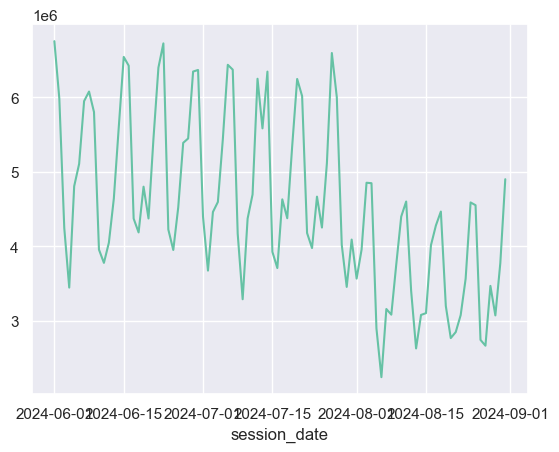

In [ ]:
df.groupby('session_date')['spend'].sum().plot()

<Axes: xlabel='session_date'>

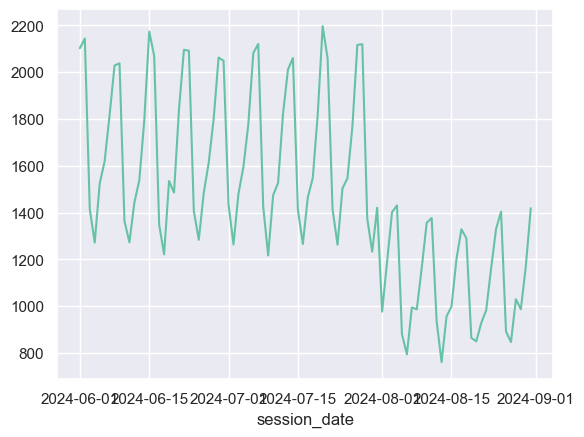

In [ ]:
df.groupby('session_date')['purchased'].sum().plot()

In [ ]:
df[df['purchased']]['spend'].mean()

3081.947515830133

In [ ]:
df[df['purchased']][df['os'] == 'Android']['spend'].mean()

/var/folders/ym/2l1gn__s5ss0_f4qd4t25z500000gq/T/ipykernel_7849/3780170145.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['purchased']][df['os'] == 'Android']['spend'].mean()


2488.610515043459

In [ ]:
df[df['purchased']][df['os'] == 'iOS']['spend'].mean()

/var/folders/ym/2l1gn__s5ss0_f4qd4t25z500000gq/T/ipykernel_7849/2167380447.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['purchased']][df['os'] == 'iOS']['spend'].mean()


4241.512455192839

In [ ]:
df.to_csv('market.csv', index=False)

Рассмотрим датасет с сессиями в интернет-магазине за некоторое время.

Приведём небольшое описание колонок датасета.

### 📄 Описание колонок в сгенерированном датасете

| Название         | Описание                                                                 |
|------------------|--------------------------------------------------------------------------|
| `user_id`        | ID пользователя (уникален на уровне пользователя)                        |
| `session_id`     | ID сессии (уникален глобально)                                           |
| `viewed`         | Флаг (bool), был ли просмотр хотя бы одного товара в сессии              |
| `added`          | Флаг (bool), был ли добавлен хотя бы один товар в корзину                |
| `purchased`      | Флаг (bool), была ли совершена покупка в этой сессии                     |
| `spend`          | Сумма покупки в рублях (0, если не было покупки)|
| `csat_answered`  | Флаг (bool), был ли заполнен CSAT-опрос по итогам сессии                 |
| `csat_score`     | Оценка удовлетворённости (от 1.0 до 5.0), если пользователь ответил. Иначе — NaN |

**Посмотрим на данные.**

In [ ]:
df = pd.read_csv('market.csv')
df

,user_id,session_id,os,session_date,viewed,added,purchased,spend,csat_answered,csat_score
0,1,1,Android,2024-07-20,True,False,False,0.00,False,NaN
1,1,2,iOS,2024-08-30,False,False,False,0.00,False,NaN
2,1,3,Android,2024-06-23,False,False,False,0.00,False,NaN
3,1,4,Android,2024-08-28,True,True,False,0.00,False,NaN
4,1,5,Android,2024-07-04,True,True,True,2049.39,False,NaN
...,...,...,...,...,...,...,...,...,...,...
3562279,508925,3562280,Android,2024-06-17,False,False,False,0.00,False,NaN
3562280,508925,3562281,Android,2024-06-04,True,False,False,0.00,False,NaN
3562281,508925,3562282,iOS,2024-06-16,True,False,False,0.00,False,NaN
3562282,508925,3562283,Android,2024-07-01,False,False,False,0.00,False,NaN


#### ✍️ Интерактив. Какие метрики будем сравнивать?

Студенты предлагают метрики, которые можно сравнить. Лучше всего сравнить конверсию в покупку и средний чек (среди купивших).

Возьмём функции из предыдущего семинара по Bootstrap

> Напомним, что мы не можем рассматривать сессии как независимые события, так как у одного пользователя могут быть несколько зависимых между собой сессий. Именно поэтому важно в Bootstrap учесть семплирование по пользователям.

In [ ]:
def run_1_iteration(data, target_col, boot_fn, stat_fn):
    data_boot = boot_fn(data, target_col)
    return stat_fn(data_boot)


def count_bootstrap_statistics(data, target_col, boot_fn, stat_fn, n_boot=10_000, n_jobs=-2):
    '''
    Подсчёт Bootstrap-статистик методом подстановки

    Параметры
        data — датафрейм с выборкой
        target_col — колонка с интересующей нас метрикой
        boot_fn — функция, реализующая Bootstrap
        stat_fn — функция, считающая статистику
        n_boot — кол-во запусков Bootstrap

    Возвращает
        boot_stat — массив Bootstrap-статистик
    '''

    boot_stat = Parallel(n_jobs=n_jobs)(delayed(run_1_iteration)(
        data, target_col, boot_fn, stat_fn)
                                        for _ in tqdm(range(n_boot), leave=False))

    return boot_stat

In [ ]:
def bootstrap_users(data, target_col, user_col='customer_id'):
    """
    Делает одну Bootstrap-выборку пользователей и возвращает все их заказы

    Параметры
        data — датафрейм с выборкой
        target_col — колонка с интересующей нас метрикой
        user_col — колонка с идентификатором пользователя

    Возвращает
        boot_data — новый датафрейм с Bootstrap-выборкой заказов.
    """

    # Получаем список уникальных пользователей
    unique_users = data[user_col].unique()

    # Делаем Bootstrap пользователей с возвращением
    sampled_users = np.random.choice(unique_users, size=len(unique_users), replace=True)

    # Собираем все заказы выбранных пользователей
    boot_data = data[data[user_col].isin(sampled_users)].copy()

    # Добавим, сколько раз каждый пользователь попал в выборку (важно для повторов)
    user_counts = pd.Series(sampled_users).value_counts()

    # Повторим строки в соответствии с количеством выборов пользователя
    boot_data = boot_data.merge(user_counts.rename("replications"), left_on=user_col, right_index=True)
    boot_data = boot_data.loc[boot_data.index.repeat(boot_data['replications'])][target_col]

    return boot_data

Напишем функцию для визуализации доверительных интервалов.

In [ ]:
def count_conf_ints(df, target_col, user_col, name_metric, alpha=0.95, n_boot=10_000):
    """
    Строит и сравнивает классический и Bootstrap-доверительные интервалы (ДИ)
    для среднего значения метрики. Визуализирует распределение Bootstrap-средних
    и длину интервалов.

    Параметры
    ----------
    df : pandas.DataFrame
        Датасет

    target_col : str
        Название колонки с метрикой метрики

    alpha : float, optional (по умолчанию = 0.95)
        Уровень доверия для построения интервалов (например, 0.95 — это 95% ДИ)

    n_boot : int, optional (по умолчанию = 10_000)
        Количество итераций Bootstrap

    precision : int, optional (по умолчанию = 0)
        Количество знаков после запятой при округлении значений для вывода

    Вывод
    -----
    На экран печатается
    - Среднее значение метрики
    - Bootstrap-доверительный интервал
    - Относительная длина доверительного интервала (в долях от среднего значения)

    Также строится гистограмма распределения Bootstrap-средних значений
    с визуализацией границ обоих интервалов

    Примечания
    ----------
    - Классический ДИ основан на t-распределении с оценкой стандартной ошибки
    - Bootstrap-интервал строится по квантилям распределения Bootstrap-средних
    - Используется визуализация на matplotlib для наглядного сравнения

    Возвращает
    ----------
    None
    """
    # --- Среднее ---
    mean = df[target_col].mean()

    # --- Bootstrap-ДИ ---
    bootstrap_means = count_bootstrap_statistics(
        df, target_col=target_col, stat_fn=np.mean, n_boot=n_boot,
        boot_fn=lambda df, target_col: bootstrap_users(df, target_col,
                                                       user_col=user_col))
    ci = (np.quantile(bootstrap_means, (1 - alpha) / 2),
          np.quantile(bootstrap_means, (1 + alpha) / 2))


    # --- Вывод ---
    print(f"Среднее по метрике {name_metric}: {mean:.4f}")
    print(f"Bootstrap 95% ДИ:     ({ci[0]:.4f}, {ci[1]:.4f})")
    print(f"Относительная длина Bootstrap-ДИ: {((ci[1] - ci[0]) / mean):.3f}")


    # --- Визуализация ---
    plt.figure(figsize=(10, 6))
    plt.hist(bootstrap_means, bins=50, color='skyblue', edgecolor='black', alpha=0.7,
        density=True)
    plt.axvline(mean, color='blue', linestyle='--', label=f'Среднее: {mean:.3f}')
    plt.axvline(ci[0], color='red', linestyle='--',
                label=f'Bootstrap {int(100 * alpha)}% ДИ')
    plt.axvline(ci[1], color='red', linestyle='--')
    plt.title(f"Доверительный интервал среднего метрики {name_metric}")
    plt.xlabel("Среднее значение (из Bootstrap-выборок)")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid(True)
    plt.show()
    return

Посчитаем и визуализируем доверительные интервалы для конверсии в покупку.

  0%|          | 0/2000 [00:00<?, ?it/s]

Среднее по метрике конверсия в покупку: 0.0381
Бутстрэп 95% ДИ:     (0.0379, 0.0383)
Относительная длина бутстрепного ДИ: 0.011


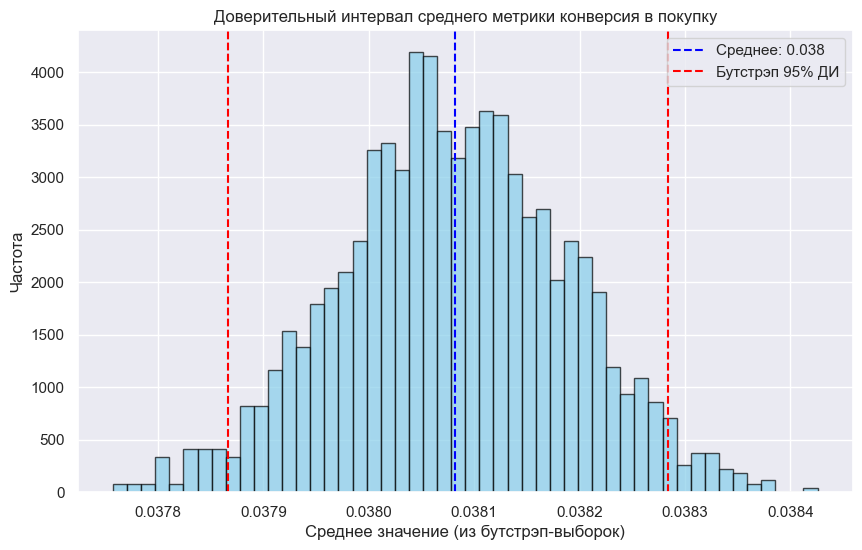

In [ ]:
count_conf_ints(df, 'purchased', 'user_id', 'конверсия в покупку', n_boot=2_000)

Посчитаем и визуализируем доверительные интервалы для среднего чека.

  0%|          | 0/10000 [00:00<?, ?it/s]

Среднее по метрике средний чек: 3081.9475
Бутстрэп 95% ДИ:     (3048.9640, 3114.7555)
Относительная длина бутстрепного ДИ: 0.021


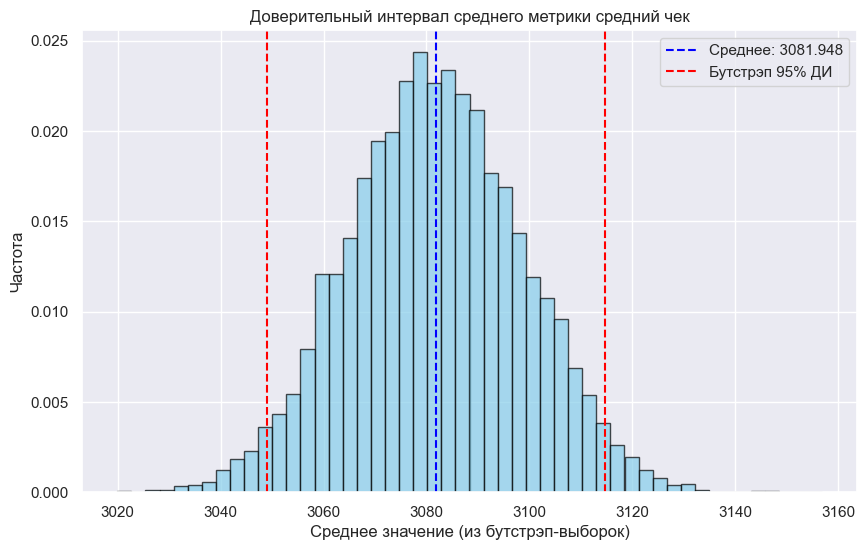

In [ ]:
df_purchased = df[df['purchased']]
count_conf_ints(df_purchased, 'spend', 'user_id', 'средний чек', n_boot=10_000)

<Axes: >

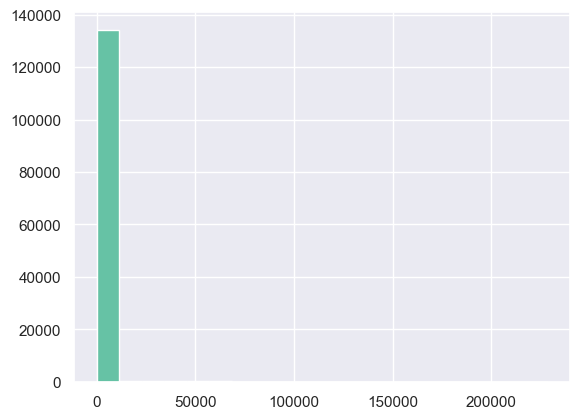

In [ ]:
df_purchased['spend'].hist(bins=20)

In [ ]:
df_purchased['spend'].max()

228477.12

In [ ]:
df_purchased['spend'].median(), df_purchased['spend'].mean()

(2223.54, 3081.947515830133)

In [ ]:
df_purchased['spend'].quantile(0.95)

6224.446999999999

<Axes: >

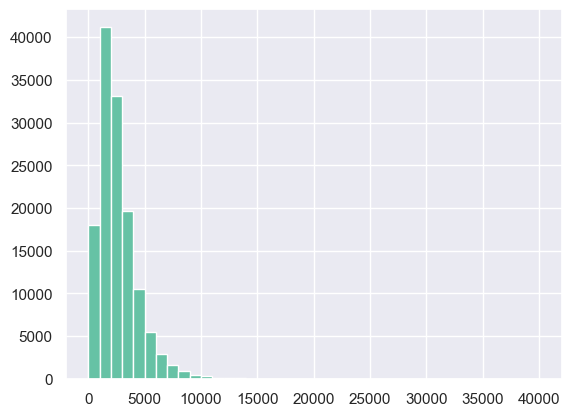

In [ ]:
df_purchased['spend'].hist(bins=np.linspace(0, 40_000, 41))

In [ ]:
df['purchased'].mean()

0.03808202827174925

**Вывод:** в данном примере более чувствительным оказалась конверсия в покупку. Длина её доверительного интервала 1.1% против 2.1% у среднего чека. Это произошло в основном из-за двух моментов.
- У среднего чека меньше наблюдений: средняя конверсия в покупку 3,8%, что при 3,5 млн сессий даёт нам чуть более 100 тыс. покупок, что значительно меньше наблюдений конверсий в покупку.
- У среднего чека есть выбросы: при медиане чуть более 2 тыс. ₽ и среднем чуть больше 3 тыс. ₽ встречается значение более 200 тыс. ₽, при этом 95% чеков меньше 6,5 тыс. ₽.

### 2.2 Достоверность

#### ✍️ Интерактив: что можно проверить на данных из достоверности?


Из достоверности на данных можно проверить несколько вещей.
- Можем ли мы доверять данным? Посмотреть Sanity Check из семинара 2.
- Есть ли смещение / ошибка выжившего? Это мы и будем смотреть на примере.

Посмотрим на средний CSAT по всем, купившим и просмотревшим.

In [ ]:
df_purchased = df[df['purchased']]
df_viewed = df[df['viewed']]

csat = df['csat_score'].mean()
csat_purchased = df_purchased['csat_score'].mean()
csat_viewed = df_viewed['csat_score'].mean()

print(f'''средний CSAT по всей выборке: {csat:.2f}''')
print(f'''средний CSAT по купившим: {csat_purchased:.2f}''')
print(f'''средний CSAT по просмотревшим: {csat_viewed:.2f}''')

средний ксат по всей выборке: 3.48
средний ксат по купившим: 4.13
средний ксат по просмотревшим: 3.66


Посмотрим также на покрытие CSAT по этим же сегментам.

In [ ]:
csat_frac = df['csat_answered'].sum() / len(df)
csat_frac_purchased = df_purchased['csat_answered'].sum() / len(df_purchased)
csat_frac_viewed = df_viewed['csat_answered'].sum() / len(df_viewed)

print(f'''покрытие CSAT по всей выборке: {csat_frac:.3f}''')
print(f'''покрытие CSAT по купившим: {csat_frac_purchased:.3f}''')
print(f'''покрытие CSAT по просмотревшим: {csat_frac_viewed:.3f}''')

покрытие ксат по всей выборке: 0.079
покрытие ксат по купившим: 0.400
покрытие ксат по просмотревшим: 0.101


Видим значительный перекос в сторону тех, кто покупает товар.

> Если мы хотим оценить CSAT по товарам, то в таком случае можно смотреть только CSAT по купившим, и никакой проблемы не будет. А вот если мы хотим смотреть, например, CSAT по сайту, то в таком случае лучше смотреть CSAT по всем, причём перевзвешенный с весами долей сегментов.

In [ ]:
df_not_viewed = df[~df['viewed']]
df_viewed_not_purchased = df[(df['viewed']) & (df['purchased'])]
df_purchased = df[df['purchased']]


csat_not_viewed = df_not_viewed['csat_score'].mean()
csat_viewed_not_purchased = df_viewed_not_purchased['csat_score'].mean()
csat_purchased = df_purchased['csat_score'].mean()

frac_not_viewed = len(df_not_viewed) / len(df)
frac_viewed_not_purchased = len(df_viewed_not_purchased) / len(df)
frac_purchased = len(df_purchased) / len(df)

In [ ]:
csats = [csat_not_viewed, csat_viewed_not_purchased, csat_purchased]
weights = [frac_not_viewed, frac_viewed_not_purchased, frac_purchased]

csat_right = np.average(csats, weights=weights)
print(f'''перевзвешенный CSAT по просмотревшим: {csat_right:.2f}''')

перевзвешенный ксат по просмотревшим: 3.17


**Вывод:** мы встретили ошибку выжившего в данных CSAT: посчитали среднюю оценку, оценку по группам и перевзвешенную оценку с весами сегментов, которая значительно отличается от изначального среднего. Это значит, что данные по CSAT нельзя считать достоверными, у них есть явное смещение.

### 2.3 Эффективность расчёта

**Ситуация:**
команда хочет измерять удовлетворённость пользователей (CSAT) с помощью развёрнутой формы-опроса (10+ вопросов) в мобильном приложении и сразу раскатить её на всех пользователей.

***Вопрос в зал:***
стоит ли внедрять такую длинную форму сразу для всех?

**Ответ:**
не стоит.

* **Риск:** длинная анкета вызовет раздражение и негатив, что может привести к оттоку и прямым денежным потерям.
* **Рекомендация:** сначала протестировать на небольшой контрольной группе (например, 1–2% пользователей), измерить:

  * уровень заполнения (отклик);
  * изменение ключевых KPI (retention, ARPU);
  * чистые денежные убытки/выгоды.

Если ценность инсайтов (улучшения продукта, рост удержания/дохода) превышает потери, постепенно расширять форму на всё больше пользователей.

### 2.4 Отлаживаемость и интерпретируемость

**Ситуация:**
к нам приходит продакт со словами: «Ура! Мы провели A/b--тест в августе и заметили повышение среднего чека, посмотри на график» (график ниже).

***Вопрос в зал:***
что делаем? Что отвечаем?

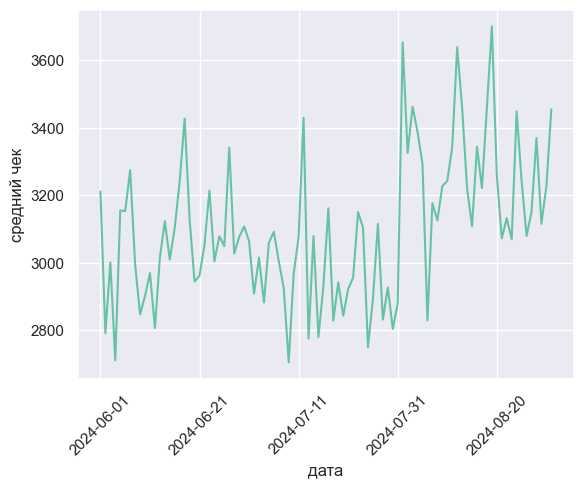

In [ ]:
plt.plot(figsize=(10, 5))
df_purchased = df[df['purchased']]
df_purchased.groupby('session_date')['spend'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('средний чек');

**Ответ студентов:** скорее всего, ответят про доверительные интервалы. Не факт, что разница статистически значима.

Давайте построим доверительные интервалы.

/var/folders/ym/2l1gn__s5ss0_f4qd4t25z500000gq/T/ipykernel_7849/464916299.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_purchased["session_date"] = pd.to_datetime(df_purchased["session_date"])


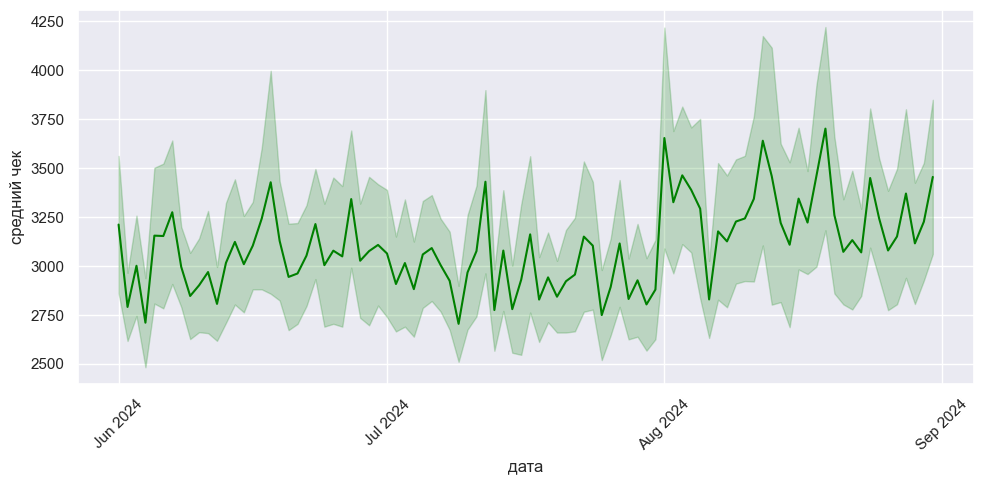

In [ ]:
# Группировка и расчёты
z = sps.norm.ppf(0.975)
df_purchased["session_date"] = pd.to_datetime(df_purchased["session_date"])
df_groupped = df_purchased.groupby("session_date")[["spend"]].mean()
df_groupped['cnt'] = df_purchased.groupby("session_date")[["spend"]].count()
df_groupped["std"] = df_purchased.groupby("session_date")["spend"].std() / np.sqrt(df_groupped['cnt'])
df_groupped["lb"] = df_groupped["spend"] - z * df_groupped["std"]
df_groupped["rb"] = df_groupped["spend"] + z * df_groupped["std"]
df_groupped = df_groupped.reset_index()

# Построение графика
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_groupped["session_date"], df_groupped["spend"], color="green")
ax.fill_between(df_groupped["session_date"], df_groupped["lb"], df_groupped["rb"], alpha=0.2, color="green")

# Настройка оси X: тики по месяцам
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

ax.set_xlabel("дата")
ax.set_ylabel("средний чек")
plt.tight_layout()
plt.show()

Попробуем посчитать скользящее среднее за неделю и убедимся, что средний чек действительно вырос.

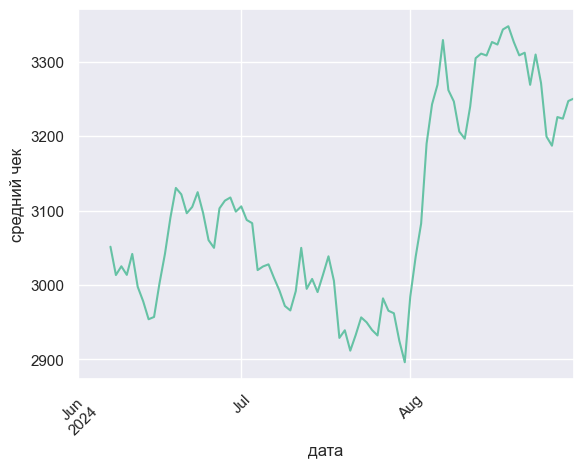

In [ ]:
df_groupped['rolling_mean'] = (df_groupped['spend'] * df_groupped['cnt']).rolling(7).mean() / df_groupped['cnt'].rolling(7).mean()
df_groupped.set_index('session_date')['rolling_mean'].plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('средний чек');

***Вопрос в зал:*** кажется, действительно тест успешен. Может ли что-то пойти не так?

**Ответ:** стоит посмотреть на GMV по дням, то есть на суммарную подневную прибыль.

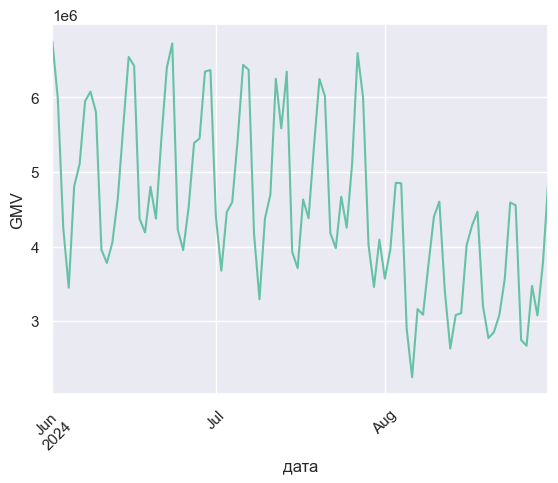

In [ ]:
df_groupped['GMV'] = (df_groupped['spend'] * df_groupped['cnt'])
df_groupped.set_index('session_date')['GMV'].plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('GMV');

Итак, подневная прибыль упала. Давайте разбираться, что пошло не так.

$GMV = AOV \times \text{кол-во покупок}$

Мы уже видели, что средний чек даже вырос, значит, упало количество покупок. Разбираемся дальше.

$\text{кол-во покупок} = DAU \times \text{конверсия в покупку}$

Давайте посмотрим на посещаемость и конверсию.

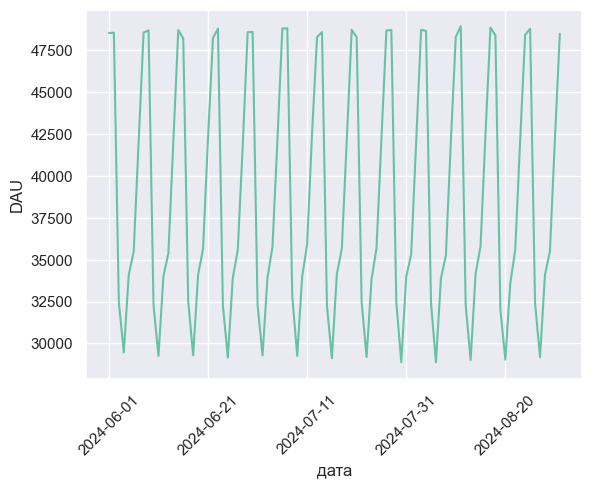

In [ ]:
df.groupby('session_date')['session_id'].count().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('DAU');

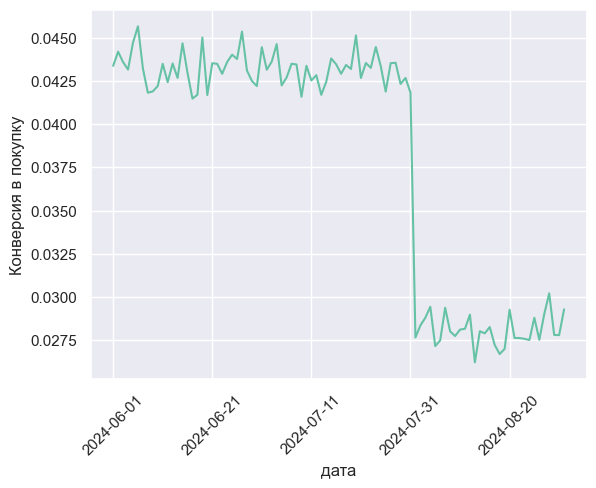

In [ ]:
df.groupby('session_date')['purchased'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('Конверсия в покупку');

Так вот в чём дело: резко упала конверсия в покупку!

***Вопрос в зал:*** что же произошло?

**Ответ:** давайте посмотрим другие конверсии. В просмотр и добавление в корзину.

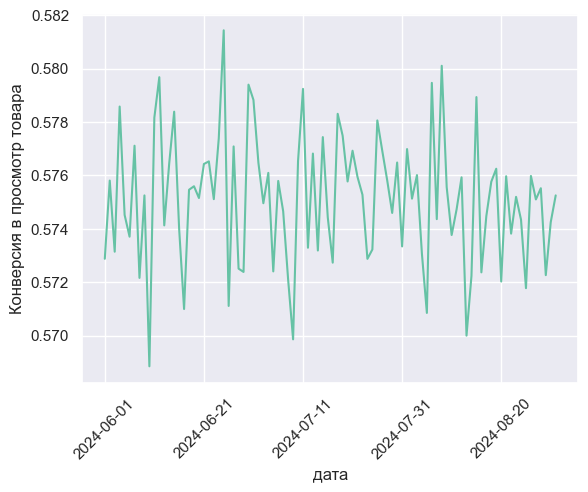

In [ ]:
df.groupby('session_date')['viewed'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('Конверсия в просмотр товара');

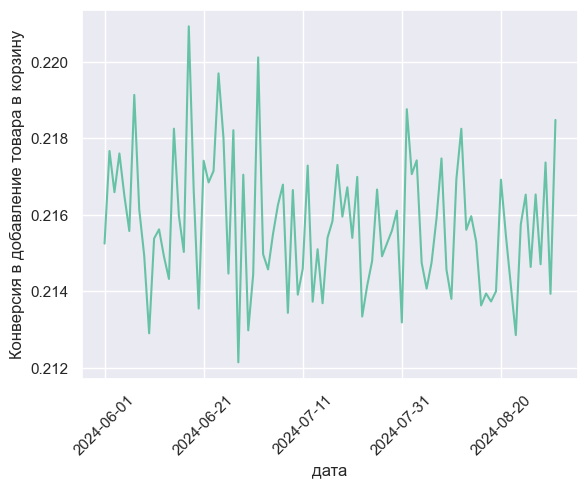

In [ ]:
df.groupby('session_date')['added'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('Конверсия в добавление товара в корзину');

Эти конверсии не изменились. Скорее всего, у нас произошел сбой в покупках. Давайте разбираться дальше, что произошло: странно, что при этом вырос средний чек.

***Вопрос в зал:*** идеи?

**Ответ:** давайте посмотрим конверсию в покупку в разрезах ОС.

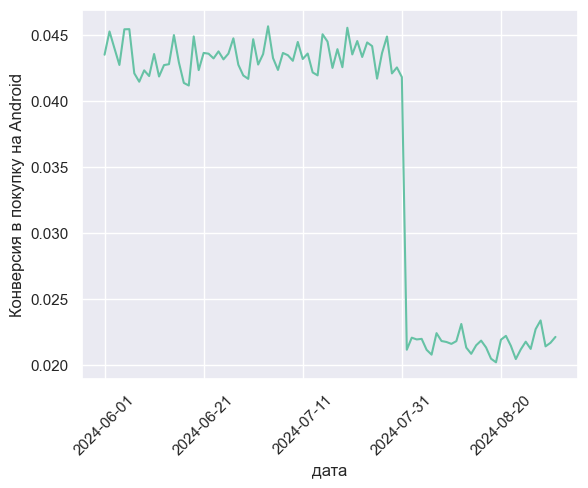

In [ ]:
df_android = df[df['os'] == 'Android']

df_android.groupby('session_date')['purchased'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('Конверсия в покупку на Android');

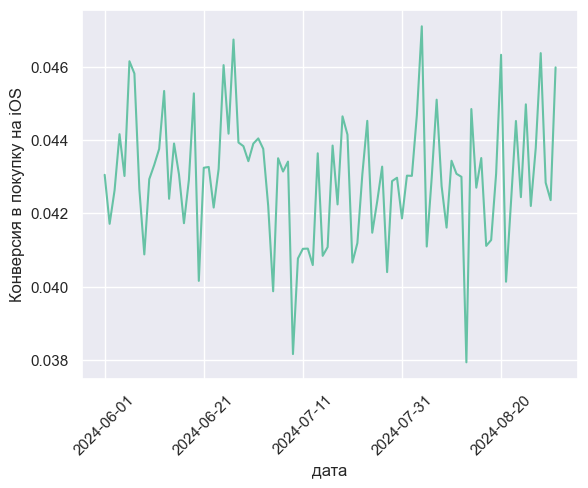

In [ ]:
df_ios = df[df['os'] == 'iOS']

df_ios.groupby('session_date')['purchased'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('Конверсия в покупку на iOS');

Конверсия в покупку на Android упала примерно в 2 раза. На практике произошло что-то из двух:
- мы что-то сломали, поэтому покупки на Android перестали стабильно работать;
- с покупками всё нормально, а вот наши данные на Android льются в систему не полностью.

***Вопрос в зал:*** а почему же средний чек вырос?

**Ответ:** давайте посмотрим средний чек в разрезах ОС.

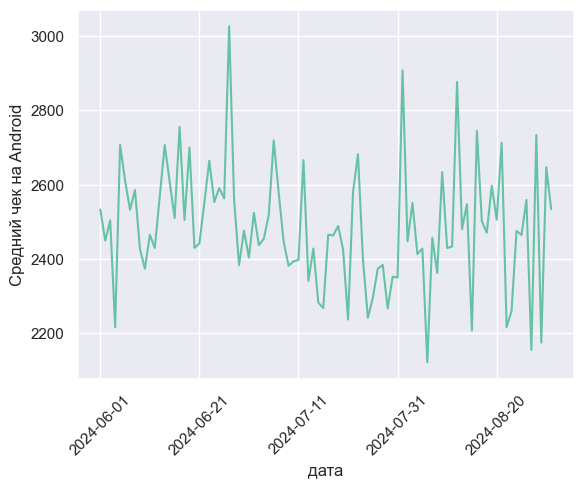

In [ ]:
df_purchased_android = df_android[df_android['purchased']]

df_purchased_android.groupby('session_date')['spend'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('Средний чек на Android');

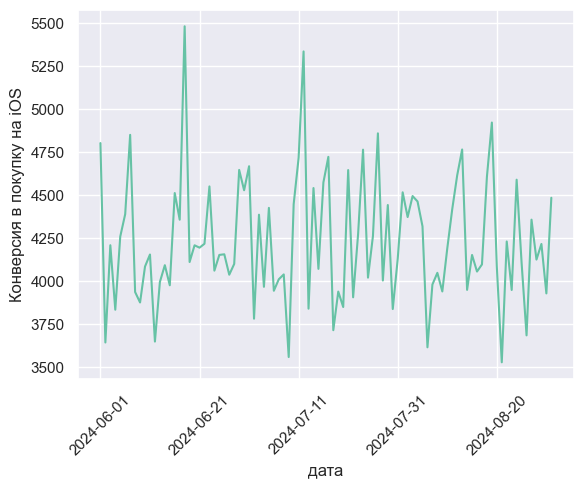

In [ ]:
df_purchased_ios = df_ios[df_ios['purchased']]

df_purchased_ios.groupby('session_date')['spend'].mean().plot()
plt.xticks(rotation=45);
plt.xlabel('дата')
plt.ylabel('Конверсия в покупку на iOS');

Средний чек по ОС не поменялся, но в на iOS он в среднем всегда выше, а покупки на Android сломались, поэтому и общий средний чек вырос.

**Вывод по задаче:** мы разобрали кейс, где декомпозировали различные метрики и разобрались, почему же произошло изменение метрик после теста. Несмотря на рост среднего чека, прибыль упала, так что в данном случае рекомендуется устранить баг (либо в системе, либо в проливании данных) на Android, а после повторить тест.

**Вывод по свойствам**
1. В данном случае средний чек показал себя как неинтерпретируемая и плохо отлаживаемая метрика:
    - интерпретируемость отсутствует, так как к нам пришёл продакт с мыслью «Средний чек вырос, значит, круто, катим изменения.», а на самом деле оказалось, что GMV упал, так что изменения ни в коем случае нельзя катить;
    - отлаживаемость низкая, так как в данном случае мы не можем декомпозировать средний чек. Да, нам помогла сегментация по ОС, и мы увидели, что средний чек по ОС не изменился, однако при его изменении мы бы не смогли понять, что повлияло: инфляция, изменение типа клиента или что-то ещё.

2. Напротив, GMV показало себя как интерпретируемая и хорошо отлаживаемая метрика:
    - интерпретируемость есть, так как все понимают, что рост GMV — это хорошо;
    - отлаживаемость высокая, так как мы смогли декомпозировать GMV и выяснить причину падения.
    
3. Число заказов и конверсия в покупку здесь — это хорошо отлаживаемые метрики, но не всегда интерпретируемые:
    - интерпретируемость может быть низкая. Пример: мы выходим на рынок дорогих клиентов/продуктов, и конверсия падает. GMV при этом может значительно вырасти из-за большого роста среднего чека;
    - отлаживаемость высокая, так как мы смогли декомпозировать эти метрики и выяснить причину падения.

### 2.5. Общий вывод по задаче

> **Идеальной метрики под все задачи не существует.** Какие-то метрики показывают себя хорошо в одном случае и плохо в другом. Важно **выбирать метрику непосредственно под задачу.** Например, если у нас продукт только запустился, то для нас были бы важнее не высокие конверсии в покупку, а больший охват аудитории.

## 3. Выбор метрики под конкретную задачу


### 3.1 ✍️Практика. Задача 1

#### Задача

Ты работаешь в стартапе мобильной игры, который только что запустился. Нужно замерить эффективность рекламной кампании. При этом есть две разные рекламные кампании, и ты хочешь провести A/B-тест, случайно разделив пользователей на две группы, чтобы определить, какая кампания эффективнее. Предложи, какую метрику использовать для оценки эффективности и как сравнить кампании.

---

#### Решение

Для оценки эффективности рекламных кампаний в стартапе мобильной игры на начальном этапе я бы рекомендовал сосредоточиться на метрике **конверсии из показа рекламы в заход в приложение**.

*Пояснение*

* Мы смотрим не просто клики, а сколько из всех пользователей, которым была показана реклама, реально запустили игру. Это позволяет оценить реальную эффективность рекламного охвата и качество трафика.

* Так как планируется провести A/B-тестирование с рандомным разделением пользователей на две группы, использование этой метрики обеспечит объективное и справедливое сравнение.

Для сравнения кампаний:

* пользователи случайно делятся на две группы, каждая из которых видит свою рекламную кампанию;
* по каждой группе измеряется **конверсия из показа в заход**;
* кампания с более высокой конверсией считается более эффективной;
* если есть возможность, дополнительно стоит анализировать метрики удержания (Retention) и монетизации (ARPU, LTV), чтобы оценить не только количество пользователей, но и их качество.

### 3.1 ✍️Практика. Задача 2


#### Задача

Ты аналитик в Wildberries. Ваша команда хочет протестировать новую версию рекомендательной системы, которая, как ожидается, будет лучше подбирать товары для конкретного пользователя. Нужно предложить метрику для оценки и сравнения качества рекомендаций.

---

#### Решение

Для оценки качества новой рекомендательной системы я бы предложил использовать **конверсию в покупку** как основную метрику.

*Пояснение*

* Целевое действие пользователя — это покупка товара, поэтому именно конверсия в покупку наиболее точно отражает эффективность рекомендаций.
* Если новая система предлагает релевантные и интересные товары, пользователи с большей вероятностью совершат покупку, что и покажет повышение конверсии.
* Дополнительно следует отслеживать **средний чек** (average order value), чтобы убедиться, что увеличение конверсии не происходит за счёт снижения стоимости покупок. В идеале средний чек должен оставаться на прежнем уровне или расти, что будет свидетельствовать о повышении качества рекомендаций с точки зрения бизнеса.

## 4. Итоги семинара

С чем выходим с занятия:

- повторили свойства метрик;
- отметили, что метрики могут показывать себя по-разному в зависимости от ситуации;
- посмотрели на практике, что означают некоторые свойства;
- поняли, что идеальных метрик не бывает;
- попрактиковались выбирать метрику под задачу.